In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3 as sql

In [3]:
conn = sql.connect("download.db")

In [4]:
members_sql=pd.read_sql('SELECT * FROM MEMBERS' , conn)
members_sql.head()

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05
1,1002,Fares,Saleh,9.0,Maadi,Active,None
2,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23
3,1004,Fares,Wahba,7.0,Maadi,inactive,2024-10-09
4,1005,Youssef,Halim,9.0,Maadi,Active,2024-05-05


In [5]:
books_sql=pd.read_sql('SELECT * FROM BOOKS' , conn)
books_sql.head()

,book_id,title,author
0,501,The Silver Kite,Amina Darwish
1,502,Desert Compass,Amina Darwish
2,503,The Lantern Maker,Adel Roushdy
3,504,Rooftop Astronomers,Adel Roushdy
4,505,Letters to the Nile,Aya Hafez


In [6]:
checkouts_sql=pd.read_sql('SELECT * FROM CHECKOUTS' , conn)
checkouts_sql.head()

,checkout_id,member_id,book_id,checkout_date,return_date
0,9263,1047,517,2024-10-21,2024-11-07
1,9340,1072,513,2025-08-24,2025-09-01
2,9231,1053,523,2024-02-04,2024-02-16
3,9129,1032,513,2025-06-21,2025-06-29
4,9370,1079,511,2025-11-11,2025-12-03


In [7]:
def sql_query(q):
    return pd.read_sql(q,conn)

In [8]:
count= '''
SELECT M.first_name, M.member_id, COUNT(C.checkout_id) AS COUNT
FROM MEMBERS M
LEFT JOIN CHECKOUTS C
ON M.member_id = C.member_id
GROUP BY M.member_id, M.first_name
'''
sql_query(count)

,first_name,member_id,COUNT
0,Salma,1001,1
1,Fares,1002,2
2,Bassel,1003,9
3,Fares,1004,0
4,Youssef,1005,3
...,...,...,...
75,Dina,1076,7
76,Lina,1077,6
77,Habiba,1078,0
78,Rana,1079,10


In [9]:
print("Books whose author'name starts with M")
like = '''
SELECT title
FROM BOOKS
WHERE author LIKE "M%"
'''
sql_query(like)

Books whose author'name starts with M


,title
0,Storms and Sailboats
1,The Clockwork Orchard
2,Notes from the Delta
3,The Glass Beehive


In [10]:
popular_books ='''
SELECT B.title, COUNT(C.checkout_id) AS Borrowed_numbers
FROM BOOKS B
JOIN CHECKOUTS C
ON B.book_id = C.book_id
GROUP BY B.title
ORDER BY Borrowed_numbers DESC
LIMIT 5
'''
sql_query(popular_books) 

,title,Borrowed_numbers
0,The Silver Kite,57
1,Fossils and Fireflies,55
2,Circuits for Beginners,46
3,Kites Over Cairo,38
4,Storms and Sailboats,25


In [11]:
active_readers ='''
SELECT M.member_id, M.first_name, COUNT(C.checkout_id) AS Borrowing_count
FROM MEMBERS M
JOIN CHECKOUTS C
ON M.member_id = C.member_id
GROUP BY M.member_id, M.first_name
ORDER BY Borrowing_count DESC
LIMIT 10
'''
sql_query(active_readers)

,member_id,first_name,Borrowing_count
0,1034,Aya,25
1,1044,Sherif,21
2,1008,Ziad,19
3,1010,Nour,18
4,1027,Mostafa,18
5,1018,Ahmed,17
6,1024,Youssef,17
7,1065,Adam,17
8,1030,Reem,16
9,1047,Sara,16


In [12]:
print("neighborhood is Maadi")
neighborhood ='''
SELECT M.member_id, M.first_name, C.checkout_date, M.neighborhood 
FROM CHECKOUTS C
JOIN MEMBERS M
ON M.member_id = C.member_id
WHERE M.neighborhood ="Maadi"
ORDER BY C.checkout_date DESC
limit 10 OFFSET 10
'''
sql_query(neighborhood)

neighborhood is Maadi


,member_id,first_name,checkout_date,neighborhood
0,1003,Bassel,2025-09-04,Maadi
1,1017,Adam,2025-08-25,Maadi
2,1008,Ziad,2025-08-23,Maadi
3,1003,Bassel,2025-08-21,Maadi
4,1018,Ahmed,2025-08-19,Maadi
5,1015,Hamza,2025-08-08,Maadi
6,1018,Ahmed,2025-08-04,Maadi
7,1013,Ziad,2025-07-27,Maadi
8,1003,Bassel,2025-07-22,Maadi
9,1009,Hassan,2025-07-22,Maadi


In [13]:
combined_sql=pd.merge(members_sql, checkouts_sql, on="member_id", how="left")
combined_sql["borrowed_books"]=combined_sql.groupby("member_id")["checkout_id"].transform("count")
combined_sql.head()

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,borrowed_books
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05,9025.0,525.0,2024-10-24,2024-11-07,1
1,1002,Fares,Saleh,9.0,Maadi,Active,None,9013.0,501.0,2024-02-16,2024-02-29,2
2,1002,Fares,Saleh,9.0,Maadi,Active,None,9095.0,507.0,2024-06-25,2024-07-07,2
3,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9051.0,513.0,2025-07-22,2025-08-18,9
4,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9068.0,501.0,2025-11-14,2025-12-03,9


In [14]:
combined_sql.shape

(409, 12)

In [15]:
json=pd.read_json("download.json")
json.head()

,book_id,genre,pages,publication_year,publisher
0,501,Adventure,128,2017.0,Nile Press
1,502,Adventure,109,2018.0,Delta House
2,503,Historical,259,NaN,Nile Press
3,504,Science,319,2009.0,Cairo Young Readers
4,505,Historical,216,2024.0,Oasis Books


In [16]:
combined_json=pd.merge(combined_sql, json, on="book_id", how="left")
combined_json.head()

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,borrowed_books,genre,pages,publication_year,publisher
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05,9025.0,525.0,2024-10-24,2024-11-07,1,Adventure,297.0,2015.0,Oasis Books
1,1002,Fares,Saleh,9.0,Maadi,Active,None,9013.0,501.0,2024-02-16,2024-02-29,2,Adventure,128.0,2017.0,Nile Press
2,1002,Fares,Saleh,9.0,Maadi,Active,None,9095.0,507.0,2024-06-25,2024-07-07,2,Science,160.0,2024.0,Nile Press
3,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9051.0,513.0,2025-07-22,2025-08-18,9,Science,294.0,2021.0,Oasis Books
4,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9068.0,501.0,2025-11-14,2025-12-03,9,Adventure,128.0,2017.0,Nile Press


In [17]:
combined_json.shape

(409, 16)

In [18]:
html = pd.read_html("download.html")
html_table = html[0]
html_table.head()

,Member ID,Book ID,Checkout Date
0,1026,522,2025-07-11
1,1049,520,2025-07-11
2,1062,525,2025-07-05
3,1065,520,2025-07-07
4,1104,515,2025-07-07


In [19]:
html_table.columns = html_table.columns.str.lower().str.replace(" ", "_")
html_table.head()

,member_id,book_id,checkout_date
0,1026,522,2025-07-11
1,1049,520,2025-07-11
2,1062,525,2025-07-05
3,1065,520,2025-07-07
4,1104,515,2025-07-07


In [20]:
html_table.shape

(26, 3)

In [21]:
combined_data= pd.concat([combined_json, html_table], ignore_index=True)
combined_data.head()

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,borrowed_books,genre,pages,publication_year,publisher
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05,9025.0,525.0,2024-10-24,2024-11-07,1.0,Adventure,297.0,2015.0,Oasis Books
1,1002,Fares,Saleh,9.0,Maadi,Active,None,9013.0,501.0,2024-02-16,2024-02-29,2.0,Adventure,128.0,2017.0,Nile Press
2,1002,Fares,Saleh,9.0,Maadi,Active,None,9095.0,507.0,2024-06-25,2024-07-07,2.0,Science,160.0,2024.0,Nile Press
3,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9051.0,513.0,2025-07-22,2025-08-18,9.0,Science,294.0,2021.0,Oasis Books
4,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9068.0,501.0,2025-11-14,2025-12-03,9.0,Adventure,128.0,2017.0,Nile Press


In [22]:
combined_data.shape

(435, 16)

In [23]:
combined_data.to_csv("task1_combined_data.csv", index=False)

In [24]:
df = pd.read_csv("task1_combined_data.csv")
df.head()

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,borrowed_books,genre,pages,publication_year,publisher
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05,9025.0,525.0,2024-10-24,2024-11-07,1.0,Adventure,297.0,2015.0,Oasis Books
1,1002,Fares,Saleh,9.0,Maadi,Active,NaN,9013.0,501.0,2024-02-16,2024-02-29,2.0,Adventure,128.0,2017.0,Nile Press
2,1002,Fares,Saleh,9.0,Maadi,Active,NaN,9095.0,507.0,2024-06-25,2024-07-07,2.0,Science,160.0,2024.0,Nile Press
3,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9051.0,513.0,2025-07-22,2025-08-18,9.0,Science,294.0,2021.0,Oasis Books
4,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9068.0,501.0,2025-11-14,2025-12-03,9.0,Adventure,128.0,2017.0,Nile Press


In [25]:
df.columns

Index(['member_id', 'first_name', 'last_name', 'grade', 'neighborhood',
       'membership_status', 'join_date', 'checkout_id', 'book_id',
       'checkout_date', 'return_date', 'borrowed_books', 'genre', 'pages',
       'publication_year', 'publisher'],
      dtype='object')

In [26]:
df.shape

(435, 16)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   member_id          435 non-null    int64  
 1   first_name         409 non-null    object 
 2   last_name          409 non-null    object 
 3   grade              371 non-null    float64
 4   neighborhood       409 non-null    object 
 5   membership_status  409 non-null    object 
 6   join_date          403 non-null    object 
 7   checkout_id        391 non-null    float64
 8   book_id            417 non-null    float64
 9   checkout_date      417 non-null    object 
 10  return_date        326 non-null    object 
 11  borrowed_books     409 non-null    float64
 12  genre              391 non-null    object 
 13  pages              391 non-null    float64
 14  publication_year   357 non-null    float64
 15  publisher          391 non-null    object 
dtypes: float64(6), int64(1), o

In [28]:
df.describe()

,member_id,grade,checkout_id,book_id,borrowed_books,pages,publication_year
count,435.000000,371.000000,391.000000,417.000000,409.000000,391.000000,357.000000
mean,1041.117241,7.560647,9192.611253,513.443645,11.723716,201.969309,2017.560224
std,26.126819,1.152419,110.279771,8.976053,7.251737,73.974175,4.523334
min,1001.000000,6.000000,9001.000000,501.000000,0.000000,104.000000,2009.000000
25%,1020.000000,7.000000,9097.500000,507.000000,6.000000,134.000000,2014.000000
50%,1038.000000,8.000000,9193.000000,513.000000,11.000000,160.000000,2017.000000
75%,1061.000000,9.000000,9287.500000,519.000000,17.000000,294.000000,2021.000000
max,1201.000000,9.000000,9383.000000,532.000000,25.000000,338.000000,2024.000000


In [29]:
df.dtypes

member_id              int64
first_name            object
last_name             object
grade                float64
neighborhood          object
membership_status     object
join_date             object
checkout_id          float64
book_id              float64
checkout_date         object
return_date           object
borrowed_books       float64
genre                 object
pages                float64
publication_year     float64
publisher             object
dtype: object

In [30]:
df["join_date"] = pd.to_datetime(df["join_date"], format="mixed")
df["return_date"] = pd.to_datetime(df["return_date"], format="mixed")
df["checkout_date"] = pd.to_datetime(df["checkout_date"], format="mixed")

In [31]:
df.isna().sum()

member_id              0
first_name            26
last_name             26
grade                 64
neighborhood          26
membership_status     26
join_date             32
checkout_id           44
book_id               18
checkout_date         18
return_date          109
borrowed_books        26
genre                 44
pages                 44
publication_year      78
publisher             44
dtype: int64

In [32]:
df["grade"] = df["grade"].fillna(df["grade"].mode()[0])

In [33]:
df["join_date"] = df["join_date"].fillna(df["join_date"].mode()[0])

In [34]:
df["checkout_date"] = df["checkout_date"].fillna(df["checkout_date"].mode()[0])

In [35]:
df["return_date"] = df["return_date"].fillna(df["return_date"].mode()[0])

In [36]:
df["genre"] = df["genre"].fillna(df["genre"].mode([0]))

In [37]:
df["pages"] = df["pages"].fillna(df["pages"].median())

In [38]:
df["publication_year"] = df["publication_year"].fillna(df["publication_year"].mode()[0])

In [39]:
df["publisher"] = df["publisher"].fillna("Unknown")

In [40]:
df["book_id"] = df["book_id"].fillna("Unknown")

In [41]:
df["checkout_id"] = df["checkout_id"].fillna("Unknown")

In [42]:
df.isna().sum()

member_id             0
first_name           26
last_name            26
grade                 0
neighborhood         26
membership_status    26
join_date             0
checkout_id           0
book_id               0
checkout_date         0
return_date           0
borrowed_books       26
genre                44
pages                 0
publication_year      0
publisher             0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(8)

In [44]:
df = df.drop_duplicates()

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df["membership_status"].value_counts()

membership_status
Active      274
Inactive     50
active       45
inactive     31
INACTIVE      1
Name: count, dtype: int64

In [47]:
df["membership_status"] = df["membership_status"].str.strip().str.title()

In [48]:
df["membership_status"].value_counts()

membership_status
Active      319
Inactive     82
Name: count, dtype: int64

In [49]:
df["genre"].value_counts()

genre
Science            106
Adventure          104
Friendship          61
Mystery             39
Historical          28
Nature              23
Science Fiction     17
Poetry               5
Name: count, dtype: int64

In [50]:
df["neighborhood"].value_counts()

neighborhood
Nasr City     100
Maadi          90
Heliopolis     87
Zamalek        58
Shubra         35
Maadi          19
zamalek         8
HELIOPOLIS      2
NASR CITY       1
Nasr  City      1
Name: count, dtype: int64

In [51]:
df["neighborhood"] = df["neighborhood"].str.strip().str.title().str.split().str.join(" ")

In [52]:
df["neighborhood"].value_counts()

neighborhood
Maadi         109
Nasr City     102
Heliopolis     89
Zamalek        66
Shubra         35
Name: count, dtype: int64

In [53]:
df["publisher"].value_counts()

publisher
Nile Press             197
Oasis Books            103
Cairo Young Readers     46
Unknown                 44
Delta House             37
Name: count, dtype: int64

In [54]:
df["first_name"].value_counts()

first_name
Ahmed      31
Ziad       29
Youssef    26
Aya        26
Mostafa    24
Sherif     24
Adam       22
Rana       19
Nour       18
Fares      17
Lina       17
Sara       16
Reem       16
Dina       16
Seif       14
Nada       13
Bassel     12
Layla      10
Malak       9
Retaj       8
Tarek       7
Hassan      5
Hamza       3
Yassin      2
Habiba      2
Menna       2
Ali         2
Karim       2
Jana        2
Amir        2
Salma       1
Hana        1
Marwan      1
Mai         1
Farida      1
Name: count, dtype: int64

In [55]:
df["first_name"] = df["first_name"].str.strip().str.title()

In [56]:
df["last_name"].value_counts()

last_name
Fahmy      51
Saleh      47
Wahba      39
Fouad      39
Hegazy     34
Rashad     33
Osman      28
Adel       25
Zaki       24
Shafik     22
Nabil      20
Halim      13
Kamel       8
Mansour     5
Ibrahim     4
Sabry       4
Badr        2
Riad        2
Gamal       1
Name: count, dtype: int64

In [57]:
df["last_name"] = df["last_name"].str.strip().str.title()

In [58]:
df.shape

(427, 16)

In [59]:
invalid_members = df[~df["member_id"].isin(members_sql["member_id"])]
invalid_members

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,borrowed_books,genre,pages,publication_year,publisher
413,1104,NaN,NaN,9.0,NaN,NaN,2025-01-22,Unknown,515.0,2025-07-07,2025-01-11,NaN,NaN,160.0,2017.0,Unknown
418,1201,NaN,NaN,9.0,NaN,NaN,2025-01-22,Unknown,509.0,2025-07-10,2025-01-11,NaN,NaN,160.0,2017.0,Unknown
420,1104,NaN,NaN,9.0,NaN,NaN,2025-01-22,Unknown,526.0,2025-07-05,2025-01-11,NaN,NaN,160.0,2017.0,Unknown
423,1150,NaN,NaN,9.0,NaN,NaN,2025-01-22,Unknown,530.0,2025-07-10,2025-01-11,NaN,NaN,160.0,2017.0,Unknown
433,1201,NaN,NaN,9.0,NaN,NaN,2025-01-22,Unknown,523.0,2025-07-08,2025-01-11,NaN,NaN,160.0,2017.0,Unknown


In [60]:
invalid_members.shape

(5, 16)

In [61]:
df_clean = df[df["member_id"].isin(members_sql["member_id"])].copy()
df_clean.head()

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,borrowed_books,genre,pages,publication_year,publisher
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05,9025.0,525.0,2024-10-24,2024-11-07,1.0,Adventure,297.0,2015.0,Oasis Books
1,1002,Fares,Saleh,9.0,Maadi,Active,2025-01-22,9013.0,501.0,2024-02-16,2024-02-29,2.0,Adventure,128.0,2017.0,Nile Press
2,1002,Fares,Saleh,9.0,Maadi,Active,2025-01-22,9095.0,507.0,2024-06-25,2024-07-07,2.0,Science,160.0,2024.0,Nile Press
3,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9051.0,513.0,2025-07-22,2025-08-18,9.0,Science,294.0,2021.0,Oasis Books
4,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9068.0,501.0,2025-11-14,2025-12-03,9.0,Adventure,128.0,2017.0,Nile Press


In [62]:
df_clean.shape

(422, 16)

In [63]:
df_clean.to_csv("task2_cleaned_data.csv", index=False)

In [64]:
fairness = pd.read_csv("task2_cleaned_data.csv")

In [65]:
groupby_m = fairness.groupby("neighborhood")["member_id"].nunique().reset_index()
groupby_m

,neighborhood,member_id
0,Heliopolis,18
1,Maadi,22
2,Nasr City,20
3,Shubra,6
4,Zamalek,14


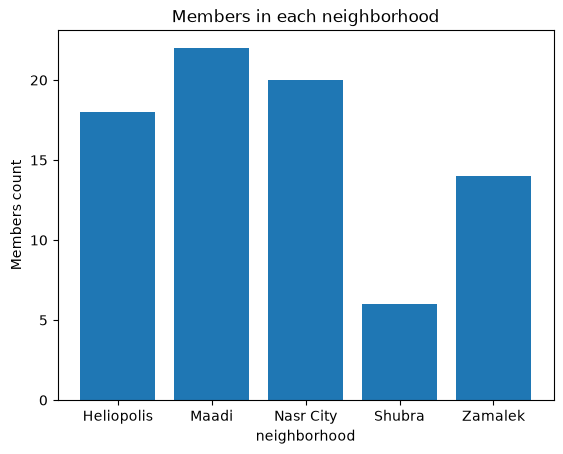

In [66]:
plt.bar(groupby_m["neighborhood"], groupby_m["member_id"])
plt.title("Members in each neighborhood")
plt.xlabel("neighborhood")
plt.ylabel("Members count")
plt.show()

In [67]:
groupby_b = fairness.groupby("neighborhood")["checkout_id"].count().reset_index()
groupby_b

,neighborhood,checkout_id
0,Heliopolis,89
1,Maadi,109
2,Nasr City,102
3,Shubra,35
4,Zamalek,66


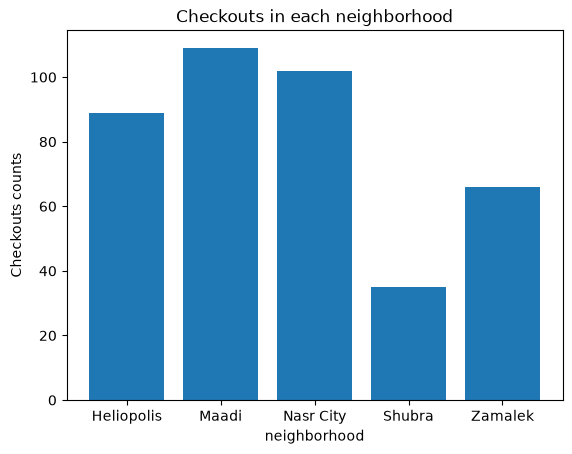

In [68]:
plt.bar(groupby_b["neighborhood"], groupby_b["checkout_id"])
plt.title("Checkouts in each neighborhood")
plt.xlabel("neighborhood")
plt.ylabel("Checkouts counts")
plt.show()

In [69]:
comparison = pd.merge(groupby_b, groupby_m, on="neighborhood", how="left")
comparison

,neighborhood,checkout_id,member_id
0,Heliopolis,89,18
1,Maadi,109,22
2,Nasr City,102,20
3,Shubra,35,6
4,Zamalek,66,14
